In [903]:
import math

import numpy as np
import cupy as cp
import numba as nb
import numba.cuda
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.ndimage
import scipy.sparse.csgraph
import rasterio

In [2]:
def point_in_disk(radius=50, linewidth=1):
    width = 2 * radius + 1
    bigx, bigy = np.meshgrid(np.arange(10 * width), np.arange(10 * width))
    x = bigx / 10 - radius - 0.5
    y = bigy / 10 - radius - 0.5
    disk = x**2 + y**2 <= radius**2
    minidisk = x**2 + y**2 <= linewidth**2
    small_disk = np.sum(np.sum(disk.reshape((width, 10, width, 10)), axis=-1), axis=-2)
    small_minidisk = np.sum(np.sum(minidisk.reshape((width, 10, width, 10)), axis=-1), axis=-2)
    small_disk[small_minidisk > 0] = 0
    small_disk = -small_disk / np.sum(small_disk)
    small_disk[small_minidisk > 0] = 1 / np.sum(small_minidisk > 0)
    return small_disk

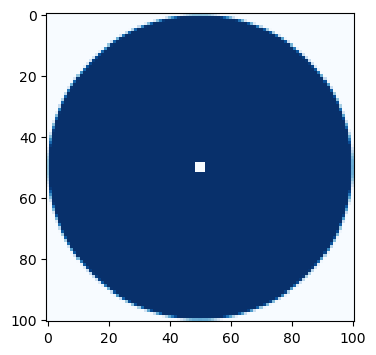

In [3]:
fig, ax = plt.subplots(figsize=(4, 4))

tmp = point_in_disk()
ax.imshow(tmp, vmin=np.nanmin(tmp), vmax=0, cmap="Blues_r")

None

In [4]:
def line_in_disk(angle, radius=50, linelength=15, linewidth=1):
    width = 2 * radius + 1
    bigx, bigy = np.meshgrid(np.arange(10 * width), np.arange(10 * width))
    x = bigx / 10 - radius - 0.5
    y = bigy / 10 - radius - 0.5
    disk = x**2 + y**2 <= radius**2
    minidisk = np.exp(-(x**2 + y**2) / 2 / linelength**2) / np.sqrt(2 * np.pi * linelength**2)
    line = np.abs(x * np.sin(-angle * np.pi/180) - y * np.cos(angle * np.pi/180)) < linewidth
    centerline = minidisk * (disk & line)
    big = -(disk / np.sum(disk)) + (centerline / np.sum(centerline))
    small = np.sum(np.sum(big.reshape((width, 10, width, 10)), axis=-1), axis=-2)
    return small

3.608224830031759e-16


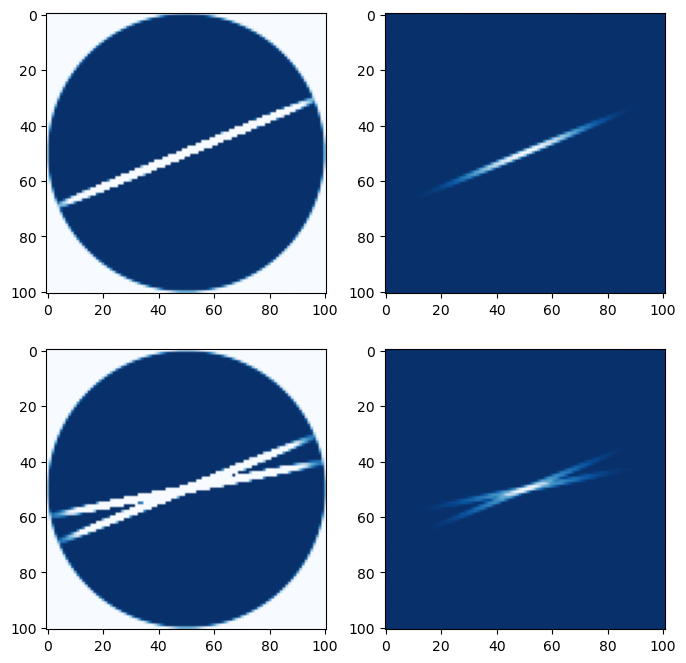

In [5]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 8))

tmp = line_in_disk(22.5)
tmp2 = line_in_disk(11.25)
print(np.sum(tmp))

ax1.imshow(tmp, vmin=np.nanmin(tmp), vmax=0, cmap="Blues_r")
ax2.imshow(tmp, vmin=0, vmax=np.nanmax(tmp), cmap="Blues_r")
ax3.imshow(tmp + tmp2, vmin=np.nanmin(tmp + tmp2), vmax=0, cmap="Blues_r")
ax4.imshow(tmp + tmp2, vmin=0, vmax=np.nanmax(tmp + tmp2), cmap="Blues_r")

None

In [6]:
with rasterio.open("../data/Sonoma_DTM_2022-OAEC-0.01-degree.tif") as file:
    elevation = file.read(1)
    transform = file.transform
    crs = file.crs

In [7]:
small_image = elevation[1800:2900, 600:1500]

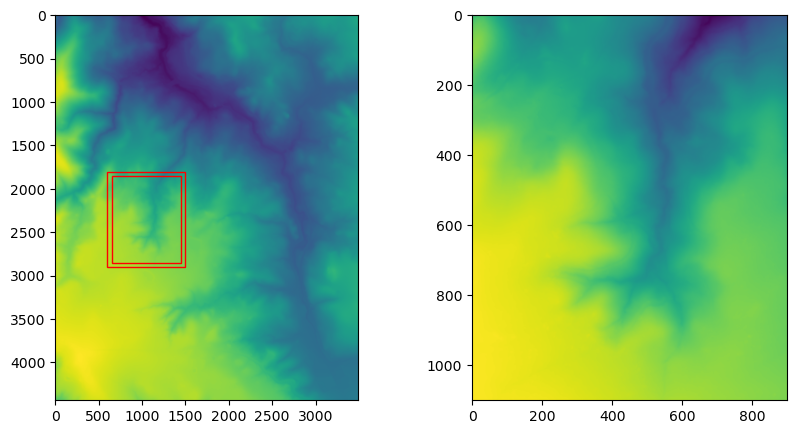

In [43]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(elevation)
ax1.add_patch(mpl.patches.Rectangle((600, 1800), 1500 - 600, 2900 - 1800, edgecolor="red", facecolor="none"))
ax1.add_patch(mpl.patches.Rectangle((600 + 50, 1800 + 50), 1500 - 600 - 100, 2900 - 1800 - 100, edgecolor="red", facecolor="none"))

ax2.imshow(small_image)

None

In [9]:
_convolve2dkernel = {}

def convolve2d(image, multikernel):
    image = cp.asarray(image, dtype=np.float32)
    multikernel = cp.asarray(multikernel, dtype=np.float32)
    output = cp.zeros(multikernel.shape[:1] + image.shape, image.dtype)

    key = (image.shape, multikernel.shape)
    if key not in _convolve2dkernel:
        imageI, imageJ = image.shape
        kernelI, kernelJ = multikernel.shape[1:]
        num_angles = multikernel.shape[0]

        @nb.cuda.jit
        def fcn(image, multikernel, output):
            ang, imi, imj = nb.cuda.grid(3)
            if imi >= imageI or imj >= imageJ:
                return

            halfi = kernelI // 2
            halfj = kernelJ // 2

            accumulate = 0
            for ki in range(kernelI):
                for kj in range(kernelJ):
                    # boundary conditions that reflect
                    i = abs(imi + ki - halfi)
                    j = abs(imj + kj - halfj)
                    i = i if i < imageI else 2*imageI - i - 1
                    j = j if j < imageJ else 2*imageJ - j - 1
                    accumulate += image[i, j] * multikernel[ang, ki, kj]

            output[ang, imi, imj] = accumulate

        _convolve2dkernel[key] = fcn

    threadsperblock = (16, 8, 8)
    blockspergrid_i = int(np.ceil(image.shape[0] / threadsperblock[1]))
    blockspergrid_j = int(np.ceil(image.shape[1] / threadsperblock[2]))
    blockspergrid = (1, blockspergrid_i, blockspergrid_j)

    _convolve2dkernel[key][blockspergrid, threadsperblock](image, multikernel, output)
    return output.get()

In [1089]:
convolution_point = convolve2d(small_image, np.stack([point_in_disk() for angle in np.arange(0, 180, 11.25)]))[:, 50:-50, 50:-50]

In [1090]:
convolution_angle = convolve2d(small_image, np.stack([line_in_disk(angle) for angle in np.arange(0, 180, 11.25)]))[:, 50:-50, 50:-50]

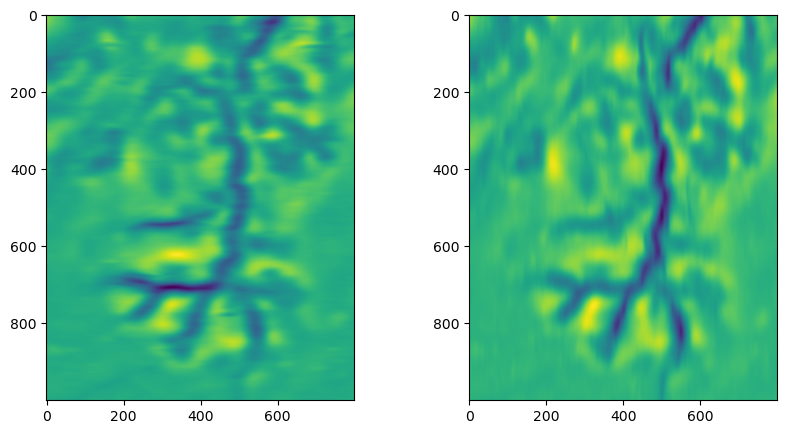

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(convolution_angle[0, :, :])
ax2.imshow(convolution_angle[8, :, :])

None

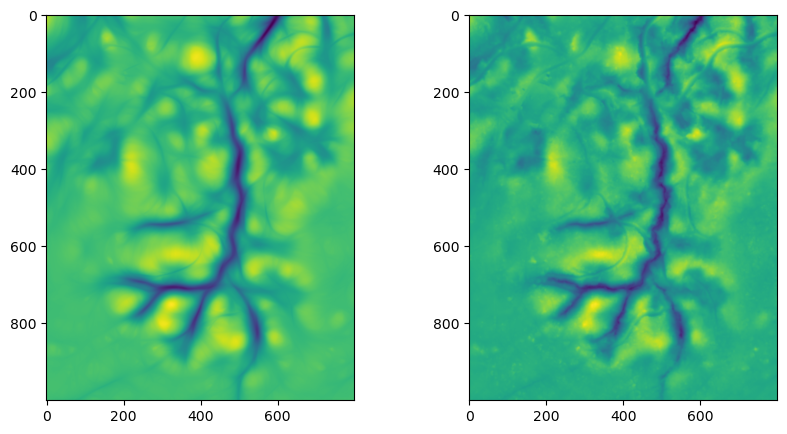

In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(np.min(convolution_angle, axis=0))
ax2.imshow(np.min(convolution_point, axis=0))

None

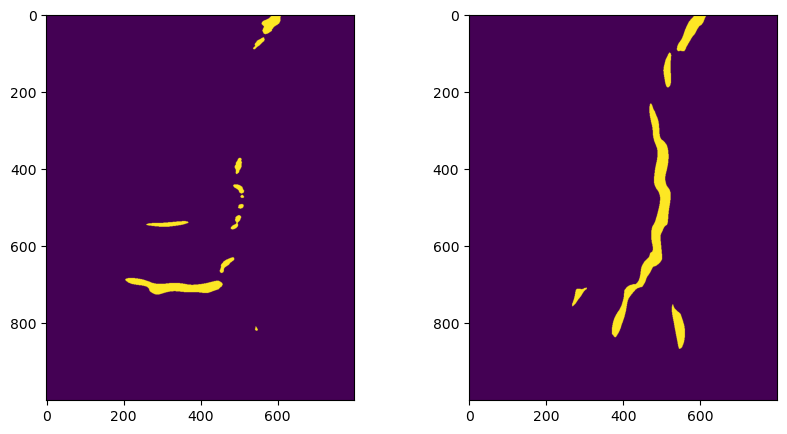

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(convolution_angle[0, :, :] < -3)
ax2.imshow(convolution_angle[8, :, :] < -3)

None

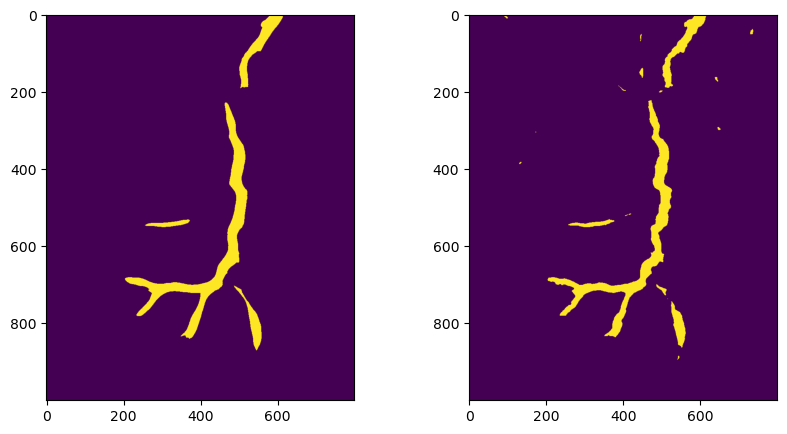

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(np.min(convolution_angle, axis=0) < -3)
ax2.imshow(np.min(convolution_point, axis=0) < -3)

None

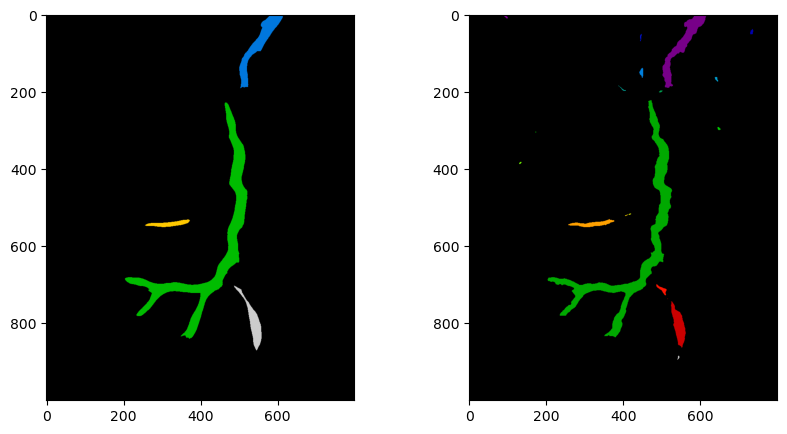

In [48]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

all8corners = scipy.ndimage.generate_binary_structure(2, 2)

ax1.imshow(scipy.ndimage.label(np.min(convolution_angle, axis=0) < -3, all8corners)[0], vmin=0, cmap="nipy_spectral")
ax2.imshow(scipy.ndimage.label(np.min(convolution_point, axis=0) < -3, all8corners)[0], vmin=0, cmap="nipy_spectral")

None

In [1090]:
convolution_angle = convolve2d(elevation, np.stack([line_in_disk(angle) for angle in np.arange(0, 180, 11.25)]))[:, 50:-50, 50:-50]

In [ ]:
# 1/sqrt(2) for sin/cos(π/4)
SQRT1_2 = 0.7071067811865475244

inv8 = 0.125   # 1/8
inv4 = 0.25    # 1/4

def best_fit(y0, y1, y2, y3, y4, y5, y6, y7):
    # Mean (orthogonality ⇒ A is just the average)
    A = inv8 * (y0 + y1 + y2 + y3 + y4 + y5 + y6 + y7)

    # Helper combos for the π/4-valued sines/cosines
    t1 = (y1 + y3) - (y5 + y7)      # weights for sin terms at ±π/4
    t2 = (y1 - y3) - (y5 - y7)      # weights for cos terms at ±π/4

    # Using: sum_k sin^2(2θk) = sum_k cos^2(2θk) = 4, cross-terms vanish
    B = inv4 * ((y2 - y6) + SQRT1_2 * t1)
    C = inv4 * ((y0 - y4) + SQRT1_2 * t2)

    return A, B, C

In [977]:
# Precomputed constants (exact forms in comments):
# sin(pi/8) = sqrt(2 - sqrt(2)) / 2
SIN_PI_8  = 0.3826834323650898
# cos(pi/8) = sqrt(2 + sqrt(2)) / 2
COS_PI_8  = 0.9238795325112867
# sqrt(1/2) = sqrt(2)/2
SQRT1_2   = 0.7071067811865476

inv16 = 0.0625  # 1/16
inv8  = 0.125   # 1/8

def best_fit(y0, y1, y2, y3, y4, y5, y6, y7, y8, y9, y10, y11, y12, y13, y14, y15):
    # Mean ⇒ A
    A = inv16 * (y0 + y1 + y2 + y3 + y4 + y5 + y6 + y7 +
                 y8 + y9 + y10 + y11 + y12 + y13 + y14 + y15)

    # Sine projection:
    # sin(k*pi/8) over k=0..15 is:
    # [0, s, m, c, 1, c, m, s, 0, -s, -m, -c, -1, -c, -m, -s]
    t_s = (y1 + y7)  - (y9 + y15)    # weights with ±sin(pi/8)
    t_m = (y2 + y6)  - (y10 + y14)   # weights with ±sqrt(1/2)
    t_c = (y3 + y5)  - (y11 + y13)   # weights with ±cos(pi/8)
    t_1 =  y4 - y12                  # weights with ±1
    S_sum = (SIN_PI_8 * t_s) + (SQRT1_2 * t_m) + (COS_PI_8 * t_c) + t_1
    B = inv8 * S_sum

    # Cosine projection:
    # cos(k*pi/8) over k=0..15 is:
    # [1, c, m, s, 0, -s, -m, -c, -1, -c, -m, -s, 0,  s,  m,  c]
    u_1 =  y0 - y8                   # weights with ±1
    u_c = (y1 + y15) - (y7 + y9)     # weights with ±cos(pi/8)
    u_m = (y2 + y14) - (y6 + y10)    # weights with ±sqrt(1/2)
    u_s = (y3 + y13) - (y5 + y11)    # weights with ±sin(pi/8)
    C_sum = u_1 + (COS_PI_8 * u_c) + (SQRT1_2 * u_m) + (SIN_PI_8 * u_s)
    C = inv8 * C_sum

    return A, B, C

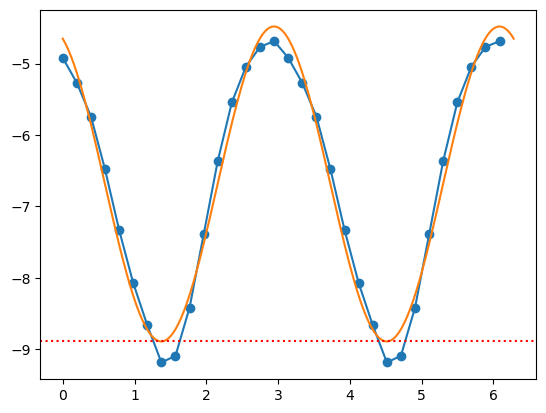

In [1117]:
fig, ax = plt.subplots()

_, i, j = sorted([
    (convolution_angle[:, i, j].min(), i, j)
     for i, j in zip(np.random.randint(0, convolution_angle.shape[1], 100000), np.random.randint(0, convolution_angle.shape[2], 100000))
])[0]

pixel = convolution_angle[:, i, j]

x = np.arange(0, 180, 11.25) * np.pi/180
ax.plot(x.tolist() + (x + np.pi).tolist(), pixel.tolist() * 2, marker="o")

A, B, C = best_fit(*pixel)
x = np.linspace(0, 2*np.pi, 320)
y = A + B*np.sin(2*x) + C*np.cos(2*x)
ax.plot(x, y)

ax.axhline(A - np.sqrt(B**2 + C**2), color="red", ls=":")

None

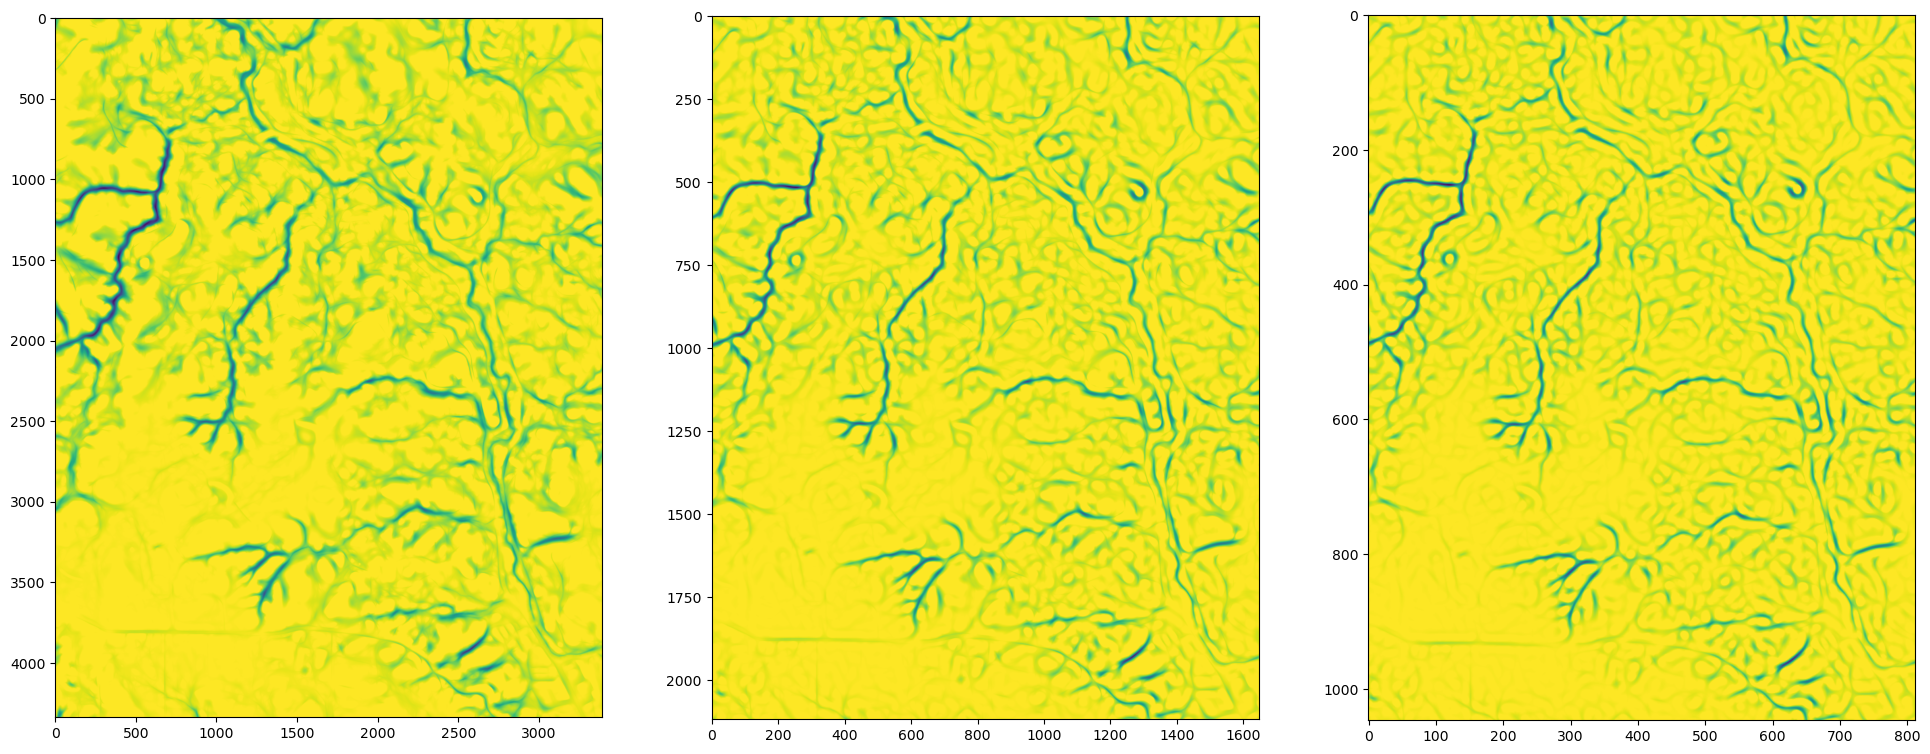

In [1204]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 10))

data_minimum = np.min(convolution_angle, axis=0)

ax1.imshow(data_minimum, vmax=0)

multikernel2 = np.stack([line_in_disk(angle, radius=25, linelength=7.5) for angle in np.arange(0, 180, 11.25)])
convolution_angle2 = convolve2d(scipy.ndimage.zoom(data_minimum, 1/2), multikernel2)[:, 25:-25, 25:-25]
data_minimum2 = np.min(convolution_angle2, axis=0)

ax2.imshow(data_minimum2, vmax=0)

multikernel3 = np.stack([line_in_disk(angle, radius=12, linelength=3.75) for angle in np.arange(0, 180, 11.25)])
convolution_angle3 = convolve2d(scipy.ndimage.zoom(data_minimum2, 1/2), multikernel3)[:, 6:-6, 6:-6]
data_minimum3 = np.min(convolution_angle3, axis=0)

ax3.imshow(data_minimum3, vmax=0)

None

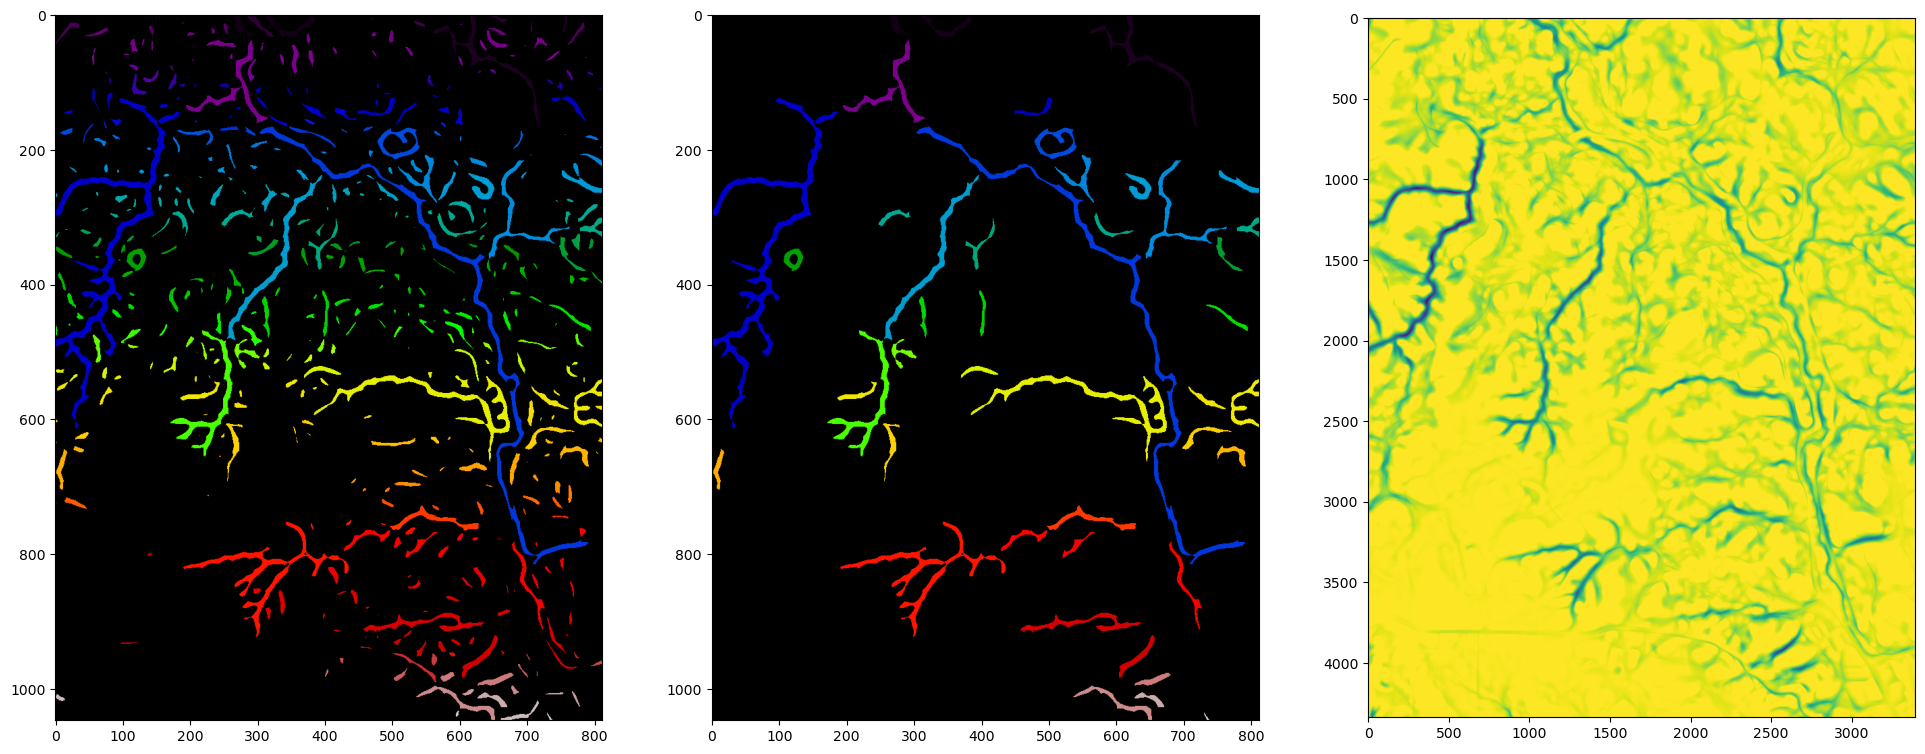

In [1206]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 10))

all8corners = scipy.ndimage.generate_binary_structure(2, 2)

labeled, num_labels = scipy.ndimage.label(data_minimum3 < -0.5, all8corners)

ax1.imshow(labeled, vmin=0, cmap="nipy_spectral")

labeled_reduced = labeled.copy()
for label in range(num_labels):
    mask = labeled == label
    if np.count_nonzero(mask) < 300:
        labeled_reduced[mask] = 0

ax2.imshow(labeled_reduced, vmin=0, cmap="nipy_spectral")

ax3.imshow(np.min(convolution_angle, axis=0), vmax=0)

None

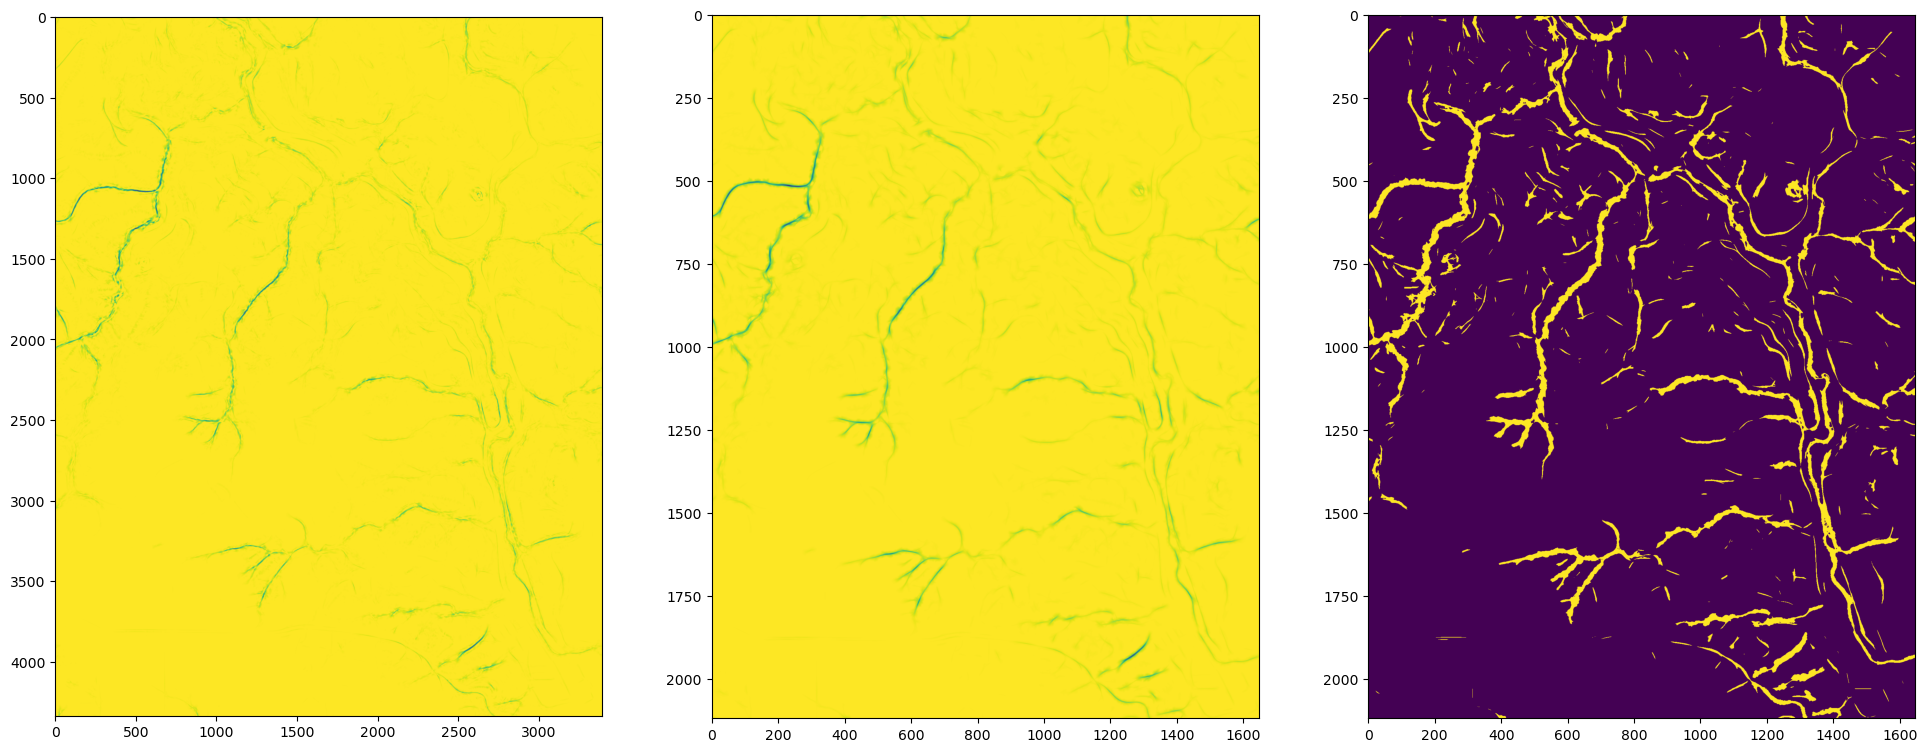

In [1207]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 10))

data_minimum = np.min(convolution_angle, axis=0)
A, B, C = best_fit(*convolution_angle)
metric = data_minimum * (A - np.sqrt(B**2 + C**2) - data_minimum)

ax1.imshow(metric, vmax=0)

multikernel2 = np.stack([line_in_disk(angle, radius=25, linelength=7.5) for angle in np.arange(0, 180, 11.25)])
convolution_angle2 = convolve2d(scipy.ndimage.zoom(metric, 1/2), multikernel2)[:, 25:-25, 25:-25]
data_minimum2 = np.min(convolution_angle2, axis=0)

ax2.imshow(data_minimum2, vmax=0)

ax3.imshow(data_minimum2 < -0.1)

None

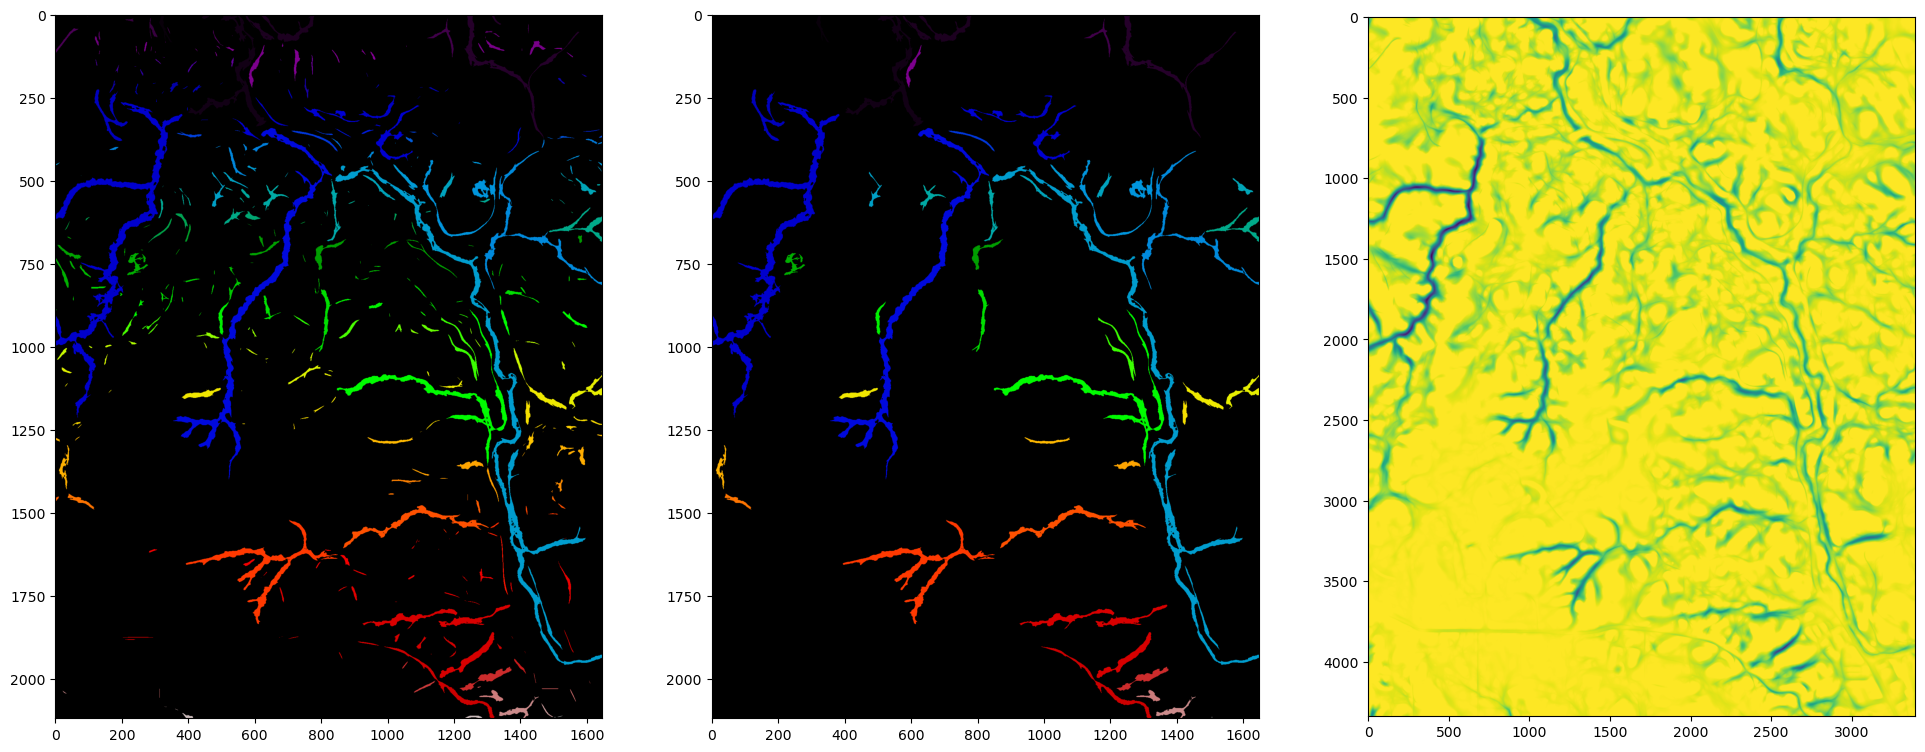

In [1208]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 10))

all8corners = scipy.ndimage.generate_binary_structure(2, 2)

labeled, num_labels = scipy.ndimage.label(data_minimum2 < -0.1, all8corners)

ax1.imshow(labeled, vmin=0, cmap="nipy_spectral")

labeled_reduced = labeled.copy()
for label in range(num_labels):
    mask = labeled == label
    if np.count_nonzero(mask) < 700:
        labeled_reduced[mask] = 0

ax2.imshow(labeled_reduced, vmin=0, cmap="nipy_spectral")

ax3.imshow(np.min(convolution_angle, axis=0), vmax=0)

None